<a href="https://colab.research.google.com/github/Salma-221/Calculator-Number-Systems-Convertor/blob/master/Medical_Insurance_Cost_Prediction_using_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')
import zipfile

zip_path = "/content/drive/MyDrive/Dataset/archive.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Mounted at /content/drive


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [14]:
df = pd.read_csv("/content/data/insurance.csv")

In [15]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [18]:
df.duplicated().sum()

np.int64(1)

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


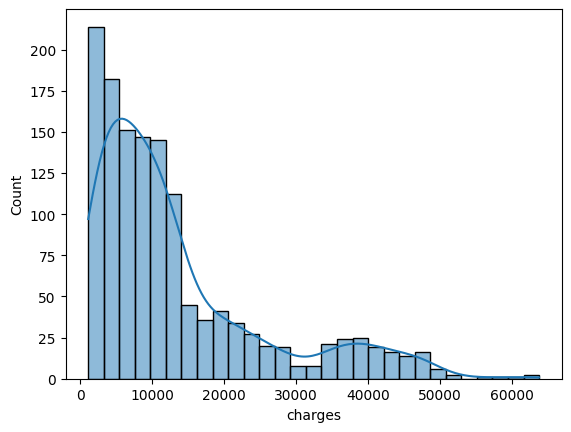

In [41]:
sns.histplot(df["charges"],kde=True)
plt.show()

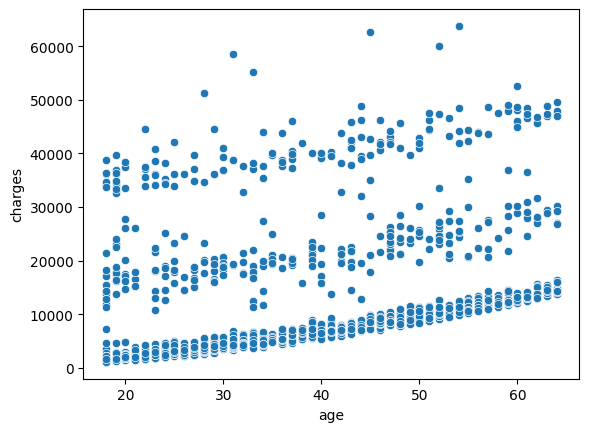

In [42]:
sns.scatterplot(x="age",y="charges",data=df)
plt.show()

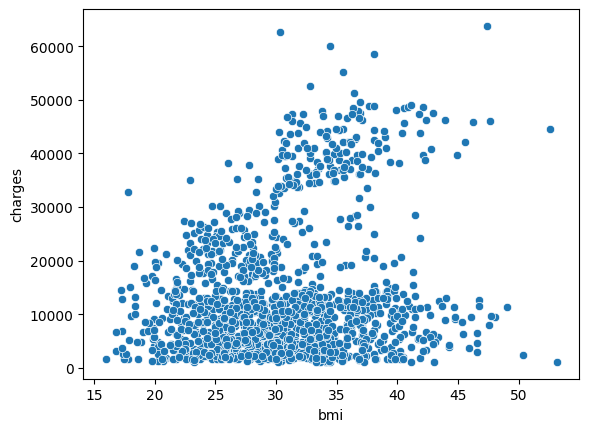

In [43]:
sns.scatterplot(x="bmi",y="charges",data=df)
plt.show()

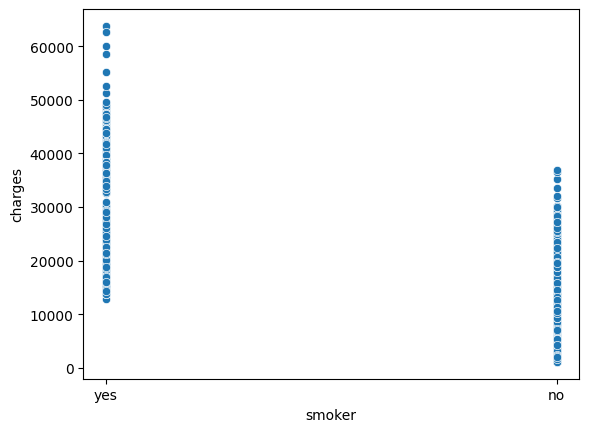

In [44]:
sns.scatterplot(x="smoker",y="charges",data=df)
plt.show()

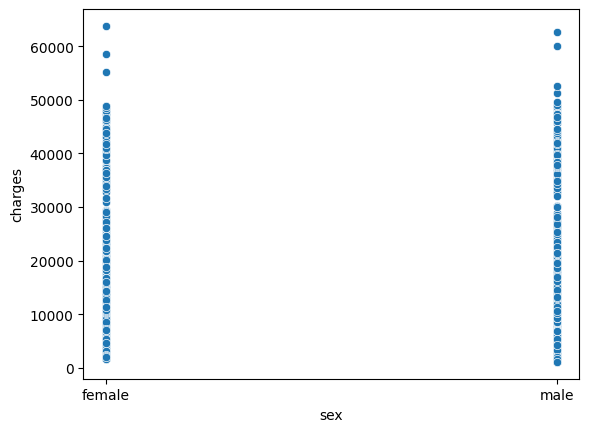

In [45]:
sns.scatterplot(x="sex",y="charges",data=df)
plt.show()

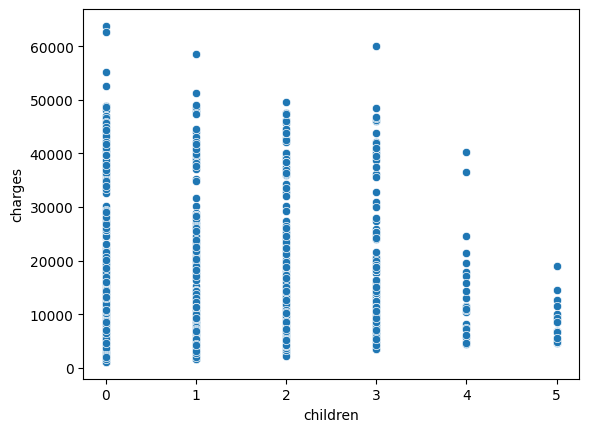

In [46]:
sns.scatterplot(x="children",y="charges",data=df)
plt.show()

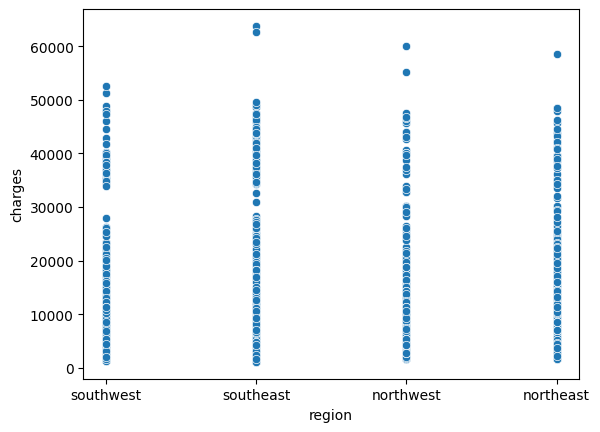

In [47]:
sns.scatterplot(x="region",y="charges",data=df)
plt.show()

In [70]:
X =df[["age","sex","bmi","region","smoker","children"]]
Y=df["charges"]


In [71]:
le = LabelEncoder()
X["sex"] = le.fit_transform(X["sex"])
X["region"] = le.fit_transform(X["region"])
X["smoker"] = le.fit_transform(X["smoker"])
X["children"] = le.fit_transform(X["children"])

/tmp/ipykernel_11297/3632806233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["sex"] = le.fit_transform(X["sex"])
/tmp/ipykernel_11297/3632806233.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["region"] = le.fit_transform(X["region"])
/tmp/ipykernel_11297/3632806233.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

In [72]:
X_train, X_test, y_train, y_test= train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

In [73]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [74]:
y_pred=model.predict(X_test)

In [75]:
r2=r2_score(y_test,y_pred)
print("r2:" , r2)

r2: 0.8068466322629111


In [76]:
mse=mean_squared_error(y_test,y_pred)
print("mse: ", mse)

mse:  35493102.611650534
